<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/H4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H4 - Production and Price Relationship Analysis

## Objective

- The objective of this notebook is to analyze whether date production has a significant relationship with producer prices in Saudi Arabia.

## Hypothesis

- H₀: Date production does not have a significant relationship with producer prices.

- H₁: Date production has a significant relationship with producer prices.

## 1) Uploading Price Dataset

- Upload and load the producer price dataset for analysis.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving prices.csv to prices.csv


## 2) Price Data Cleaning

- This part filters producer price data and prepares price values in USD and Saudi Riyals.

In [2]:
import pandas as pd

# Load price dataset
df = pd.read_csv("prices.csv")

# Keep only producer price in USD
price_usd = df[df["Element"] == "Producer Price (USD/tonne)"][["Year", "Value"]]
price_usd = price_usd.rename(columns={"Value": "Price_USD"})

# Convert year and price columns to numeric values
price_usd["Year"] = pd.to_numeric(price_usd["Year"], errors="coerce")
price_usd["Price_USD"] = pd.to_numeric(price_usd["Price_USD"], errors="coerce")
price_usd = price_usd.dropna()

# Check if local currency price data exists
local_mask = df["Element"].astype(str).str.contains("Local Currency", case=False, na=False)

if local_mask.any():
    price_local = df[local_mask][["Year", "Value"]].copy()
    price_local = price_local.rename(columns={"Value": "Price_Local"})

    price_df = pd.merge(price_usd, price_local, on="Year", how="inner")

    print("\nLocal currency data found in FAOSTAT.")
else:
# Convert USD price to SAR using fixed exchange rate
    price_df = price_usd.copy()
    price_df["Price_Local_SAR"] = price_df["Price_USD"] * 3.75

# Sort price data by year
price_df = price_df.sort_values("Year").reset_index(drop=True)
price_df.head()

,Year,Price_USD,Price_Local_SAR
0,2000,3263.3,12237.375
1,2001,3313.1,12424.125
2,2002,3307.1,12401.625
3,2003,3312.5,12421.875
4,2009,3781.3,14179.875


## 3) Uploading Production Dataset

- Upload and load the date production dataset for analysis.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving production (2).csv to production (2).csv


## 4) Production Data Cleaning

- This part filters the dataset to keep only production values and prepares log production.

In [5]:
import pandas as pd
import numpy as np

# Load production dataset
df_prod = pd.read_csv("production (2).csv")

# Keep only production rows
prod_df = df_prod[df_prod["Element"] == "Production"].copy()

# Keep only year and production value
prod_df = prod_df[["Year", "Value"]]
prod_df = prod_df.rename(columns={"Value": "Production"})

# Convert columns to numeric values
prod_df["Year"] = pd.to_numeric(prod_df["Year"], errors="coerce")
prod_df["Production"] = pd.to_numeric(prod_df["Production"], errors="coerce")

# Sort data and create log production variable
prod_df = prod_df.sort_values("Year").reset_index(drop=True)
prod_df["Log_Production"] = np.log(prod_df["Production"])
prod_df.head()

,Year,Production,Log_Production
0,2000,734844.0,13.507414
1,2001,817887.0,13.614479
2,2002,829540.0,13.628627
3,2003,884088.0,13.692312
4,2004,941293.0,13.755010


## 5) Merging Price and Production Data

- This part merges production and price data by year.

In [6]:
# Merge production and price datasets using year
df_merged = pd.merge(price_df, prod_df, on="Year", how="inner")
df_merged.head()

,Year,Price_USD,Price_Local_SAR,Production,Log_Production
0,2000,3263.3,12237.375,734844.0,13.507414
1,2001,3313.1,12424.125,817887.0,13.614479
2,2002,3307.1,12401.625,829540.0,13.628627
3,2003,3312.5,12421.875,884088.0,13.692312
4,2009,3781.3,14179.875,991660.0,13.807136


## 6) Spearman Correlation Test

- This part tests whether production and producer prices have a significant monotonic relationship.

In [7]:
from scipy.stats import spearmanr

# Calculate Spearman correlation for production and USD price
corr_usd, p_usd = spearmanr(df_merged["Production"], df_merged["Price_USD"])

# Calculate Spearman correlation for production and SAR price
corr_sar, p_sar = spearmanr(df_merged["Production"], df_merged["Price_Local_SAR"])

print("USD Correlation:", corr_usd, "p-value:", p_usd)
print("SAR Correlation:", corr_sar, "p-value:", p_sar)

USD Correlation: -0.27555948242923645 p-value: 0.25350690764450096
SAR Correlation: -0.27555948242923645 p-value: 0.25350690764450096


## Results

- The Spearman correlation between production and price was -0.276 for both USD and SAR prices.

- The p-value was 0.254, which is greater than 0.05.

- Since the p-value is above 0.05, we fail to reject the null hypothesis (H₀).

- This means there is not enough statistical evidence to conclude that production has a significant relationship with producer prices.

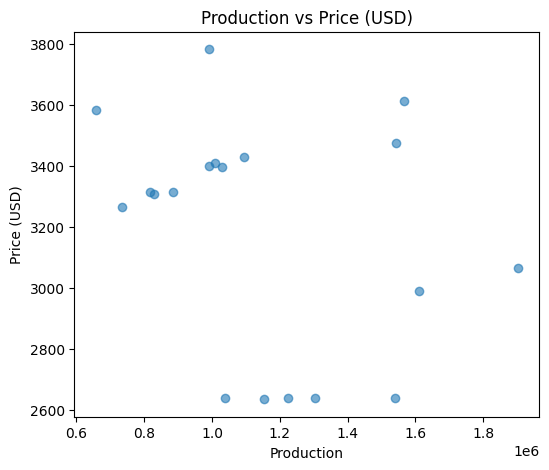

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# Create scatter plot
plt.scatter(df_merged["Production"], df_merged["Price_USD"], alpha=0.6)

plt.xlabel("Production")
plt.ylabel("Price (USD)")
plt.title("Production vs Price (USD)")

plt.show()

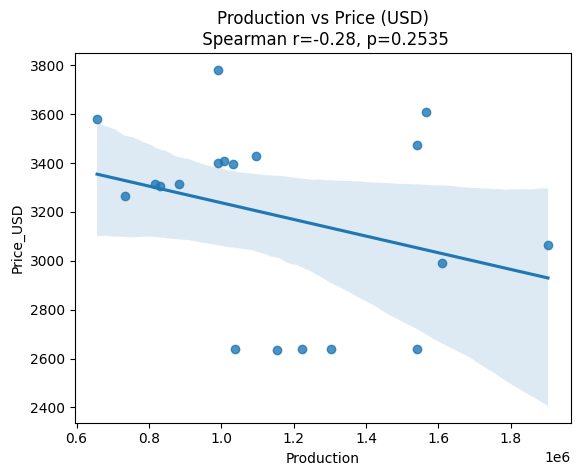

In [9]:
import seaborn as sns

# Create regression plot
sns.regplot(x="Production", y="Price_USD", data=df_merged)

plt.title(f"Production vs Price (USD)\n Spearman r={corr_usd:.2f}, p={p_usd:.4f}")
plt.show()

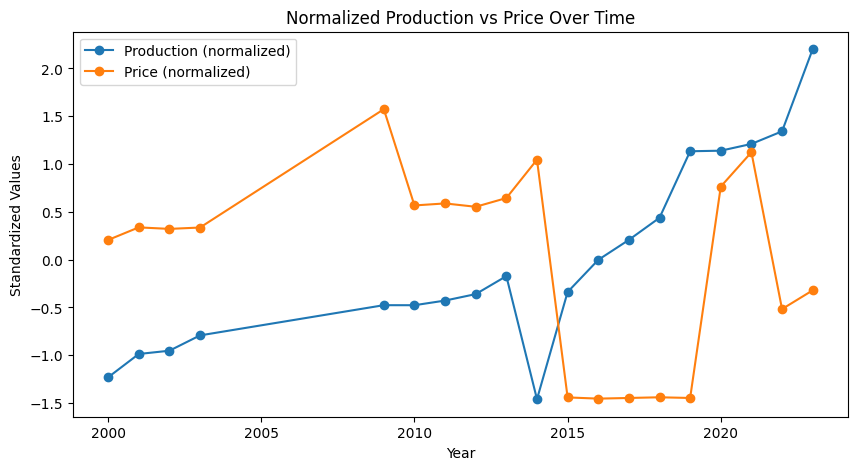

In [11]:
# Standardize production and price values
df_merged["Production_norm"] = (df_merged["Production"] - df_merged["Production"].mean()) / df_merged["Production"].std()
df_merged["Price_norm"] = (df_merged["Price_USD"] - df_merged["Price_USD"].mean()) / df_merged["Price_USD"].std()

plt.figure(figsize=(10,5))

# Plot normalized production and price over time
plt.plot(df_merged["Year"], df_merged["Production_norm"], marker="o", label="Production (normalized)")
plt.plot(df_merged["Year"], df_merged["Price_norm"], marker="o", label="Price (normalized)")

plt.title("Normalized Production vs Price Over Time")
plt.xlabel("Year")
plt.ylabel("Standardized Values")

plt.legend()
plt.show()

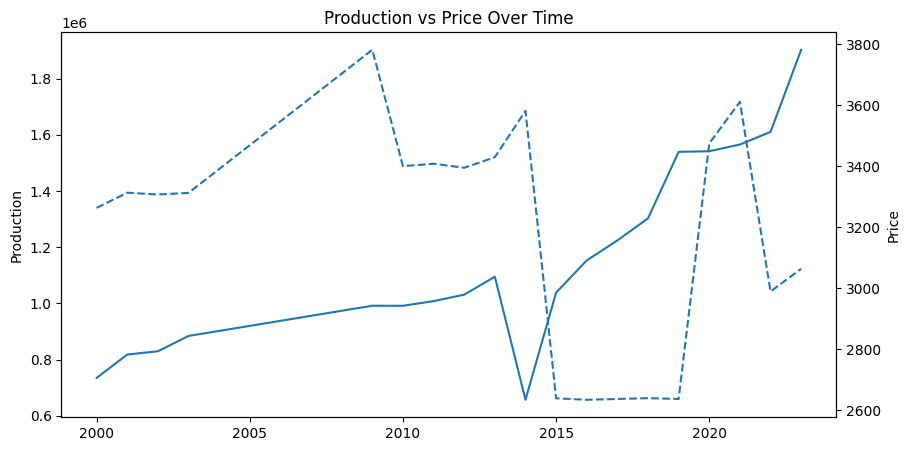

In [13]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Plot production on the first axis
ax1.plot(df_merged["Year"], df_merged["Production"], label="Production")
ax1.set_ylabel("Production")

# Plot price on the second axis
ax2 = ax1.twinx()
ax2.plot(df_merged["Year"], df_merged["Price_USD"], linestyle="--", label="Price (USD)")
ax2.set_ylabel("Price")

plt.title("Production vs Price Over Time")

plt.show()